# Test results & coverage

Test pass rates, convergence to green, intents coverage and code coverage per model, from `TestResults/` (+ `UserIntents/` as the intent denominator).

In [1]:
STORY_ID = "CPD-LC-001-001"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tdd_results as tdd

tdd.setup_theme()
data = tdd.load_all(STORY_ID)
MODELS = tdd.discover_models(STORY_ID)
PAL = tdd.model_palette(MODELS)        # fixed model -> color, used everywhere
HUE = list(PAL)                        # fixed hue_order, used everywhere

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print(f"story: {STORY_ID} | models: {MODELS}")
print("palette:", PAL)
if tdd.load_warnings:
    print(f"{len(tdd.load_warnings)} load warnings -> tdd.load_warnings")

story: CPD-LC-001-001 | models: ['Kimi-K2.5', 'grok-4.5']
palette: {'Kimi-K2.5': '#2a78d6', 'grok-4.5': '#1baf7a'}


## Final test pass rate per iteration

Where each iteration *ended*. Markers show actual iterations; a flat line at
1.0 means every iteration finished fully green.

**Chart & table columns** — chart: `iteration` (x); `pass rate (final run)` (y) — passed÷total of the run's last test execution; color — model. Table: the same final runs with `total`, `passed`, `failed`, `skipped` test-method counts.

,model,iteration,total,passed,failed,skipped
0,Kimi-K2.5,1,24,24,0,0
1,Kimi-K2.5,2,24,24,0,0
2,Kimi-K2.5,3,24,24,0,0
3,Kimi-K2.5,4,24,24,0,0
4,Kimi-K2.5,5,24,24,0,0
5,Kimi-K2.5,6,24,24,0,0
6,grok-4.5,1,24,24,0,0
7,grok-4.5,2,24,24,0,0
8,grok-4.5,3,24,24,0,0
9,grok-4.5,4,24,24,0,0


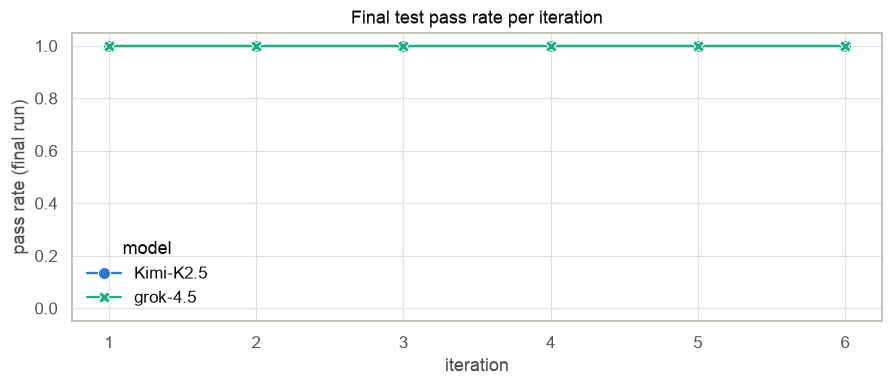

In [3]:
t = data["test"]
tfin = tdd.finals(t)
if tfin.empty:
    print("No test data.")
else:
    fig, ax = plt.subplots(figsize=(8, 3.4))
    sns.lineplot(data=tfin, x="iteration", y="pass_rate", hue="model",
                 style="model", hue_order=HUE, style_order=HUE, palette=PAL,
                 markers=True, dashes=False, estimator=None, markersize=8, ax=ax)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("pass rate (final run)")
    ax.set_title("Final test pass rate per iteration")
    display(tfin[["model", "iteration", "total", "passed", "failed", "skipped"]]
            .sort_values(["model", "iteration"]).reset_index(drop=True))

## Test outcome composition (final runs, all iterations pooled)

Left: proportions — how green is each model. Right: absolute counts —
models emit different numbers of tests, which proportions alone hide.

**Chart columns** — `model` (y); bar segments — final-run test methods by outcome (`passed` green / `failed` red / `skipped` gray), summed over that model's runs; left panel x — proportion of outcomes (0–1); right panel x — absolute test counts (segment labels).

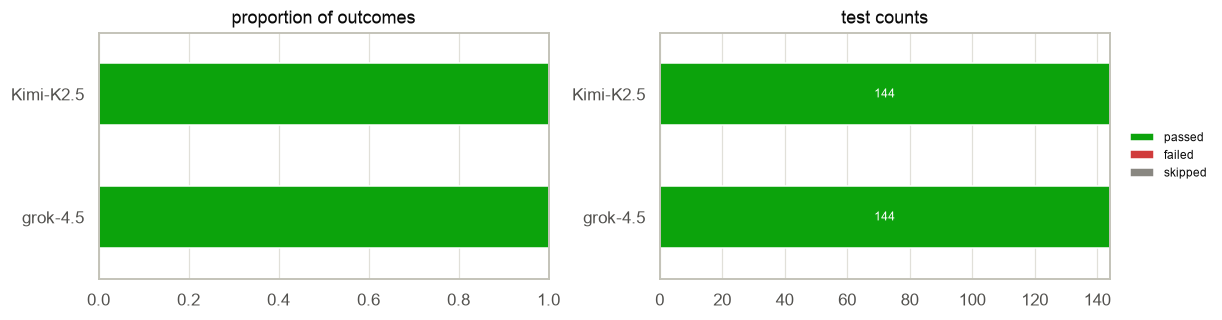

In [4]:
if tfin.empty:
    print("No test data.")
else:
    comp = tfin.groupby("model")[["passed", "failed", "skipped"]].sum().reindex(HUE)
    colors = [tdd.OUTCOME_COLORS[c] for c in comp.columns]
    frac = comp.div(comp.sum(axis=1), axis=0)
    fig, axes = plt.subplots(1, 2, figsize=(11, 2.8))
    frac.plot(kind="barh", stacked=True, color=colors, ax=axes[0], legend=False)
    axes[0].set_title("proportion of outcomes")
    axes[0].set_xlim(0, 1)
    comp.plot(kind="barh", stacked=True, color=colors, ax=axes[1])
    for container in axes[1].containers:
        axes[1].bar_label(container, label_type="center", fontsize=8, color="white",
                          labels=[f"{int(v)}" if v else "" for v in container.datavalues])
    axes[1].set_title("test counts")
    axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    for ax in axes:
        ax.set_ylabel("")
        ax.invert_yaxis()

## Convergence to green within each iteration

Pass rate at every successive test execution. How quickly does each model
climb to 1.0 — and does it stay there?

**Chart columns** — one panel per `iteration`: `attempt #` (x) — chronological test execution within the run; `pass rate` (y) — passed÷total at that attempt; line color — model; dotted line — fully green (1.0).

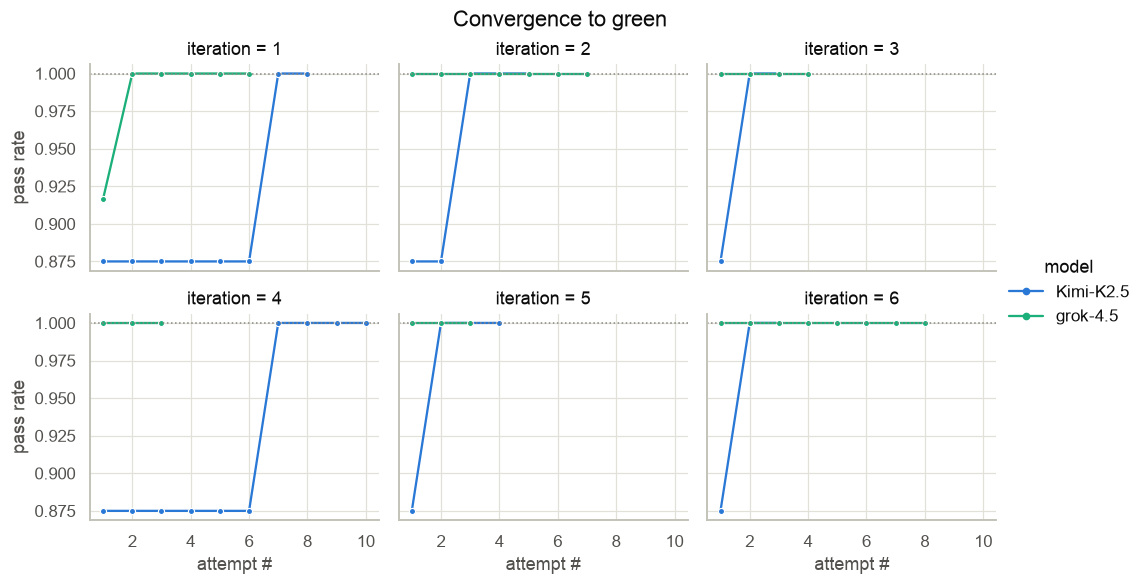

In [5]:
if t.empty:
    print("No test data.")
else:
    g = sns.relplot(data=t, kind="line", x="attempt", y="pass_rate",
                    hue="model", col="iteration", col_wrap=3, hue_order=HUE,
                    palette=PAL, estimator=None, marker="o", markersize=4,
                    height=2.6, aspect=1.2)
    for ax in g.axes.flat:
        ax.axhline(1.0, ls=":", color=tdd.INK["muted"], lw=1)
    g.set_axis_labels("attempt #", "pass rate")
    g.figure.suptitle("Convergence to green", y=1.02)

## Attempts until first fully-green test run

The concrete cost of reaching green. Cells that never reached a successful
run in an iteration are listed below the chart.

**Chart columns** — `iteration` (x); `attempts to first green` (y) — earliest `attempt #` whose test execution reported status `success`, i.e. every test passing (lower = cheaper); bar color — model. The list below names runs that never got there (`model`, `iteration`).

Every (model, iteration) cell eventually reached green.


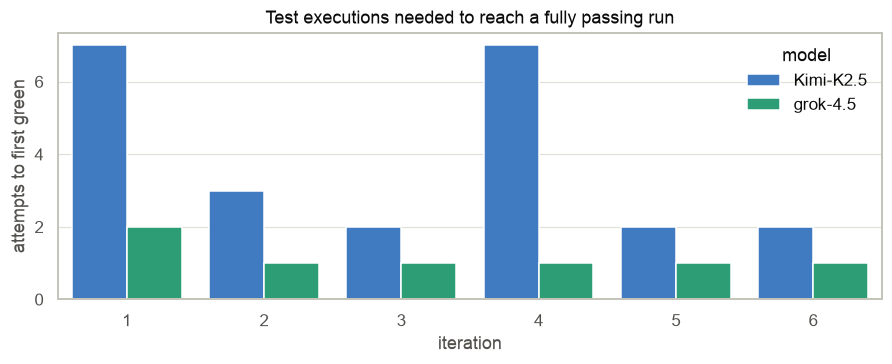

In [6]:
if t.empty:
    print("No test data.")
else:
    green = t[t["status"] == "success"]
    first = (green.groupby(["model", "iteration"])["attempt"].min()
                  .reset_index(name="attempts_to_green"))
    if first.empty:
        print("No iteration ever reached a green run.")
    else:
        fig, ax = plt.subplots(figsize=(8, 3.2))
        sns.barplot(data=first, x="iteration", y="attempts_to_green",
                    hue="model", hue_order=HUE, palette=PAL, ax=ax)
        ax.set_ylabel("attempts to first green")
        ax.set_title("Test executions needed to reach a fully passing run")
    cells = t[["model", "iteration"]].drop_duplicates()
    never = cells.merge(first, on=["model", "iteration"], how="left")
    never = never[never["attempts_to_green"].isna()]
    if never.empty:
        print("Every (model, iteration) cell eventually reached green.")
    else:
        print("Never reached green:")
        display(never[["model", "iteration"]].reset_index(drop=True))

## Test methods emitted vs confirmed intents

The story defines a fixed set of confirmed test intents (dashed line).
Bars are test methods the test-generation stage emitted per iteration
(points = individual iterations).

**Chart & table columns** — chart: `model` (x); `test methods emitted` (y) — `testMethodsEmitted` reported by the test-generation stage (bar — mean over runs; dots — runs); dashed line — the story's total confirmed intents. Table: `layer` — architecture layer of the intents; `n_intents` — confirmed intents in that layer.

,story,layer,n_intents
0,CPD-LC-001-001,Application,4
1,CPD-LC-001-001,Domain,10
2,CPD-LC-001-001,Infrastructure,3
3,CPD-LC-001-001,Presentation,4


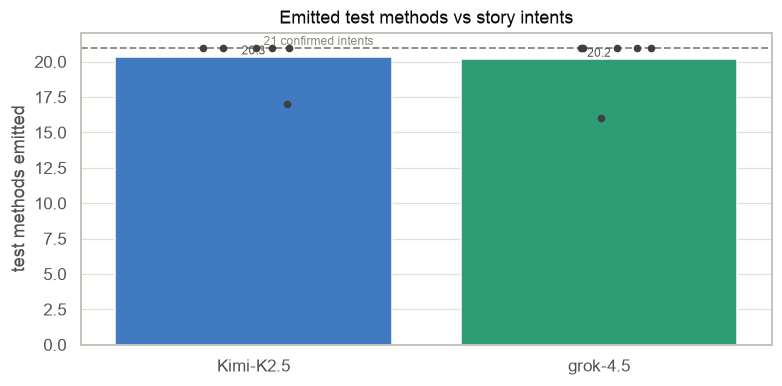

In [7]:
stages = data["stages"]
tg = stages.query("stage == 'test-generation'") if not stages.empty else stages
intents = data["intents"]
if tg.empty or tg["tg_test_methods"].isna().all():
    print("No test-generation stage results.")
else:
    fig, ax = plt.subplots(figsize=(7, 3.4))
    sns.barplot(data=tg, x="model", y="tg_test_methods", order=HUE, hue="model",
                hue_order=HUE, palette=PAL, legend=False,
                estimator="mean", errorbar=None, ax=ax)
    sns.stripplot(data=tg, x="model", y="tg_test_methods", order=HUE,
                  color=".25", size=5, jitter=0.15, ax=ax)
    if not intents.empty:
        total = intents["n_intents"].sum()
        ax.axhline(total, ls="--", color=tdd.INK["muted"], lw=1.2)
        ax.text(0.02, total, f" {total} confirmed intents", va="bottom",
                fontsize=8, color=tdd.INK["muted"])
    tdd.label_bars(ax, fmt="%.1f")
    ax.set_ylabel("test methods emitted")
    ax.set_xlabel("")
    ax.set_title("Emitted test methods vs story intents")
    if not intents.empty:
        display(intents)

## Coverage per iteration (final runs)

Line rate solid, branch rate dashed — same 0–1 scale, so one axis is honest.

**Chart & table columns** — chart: `iteration` (x); `coverage rate` (y, 0–1) — from the run's final coverage report; color — model; line style — kind (`line_rate` solid, `branch_rate` dashed). Table: final `line_rate` per `iteration` (rows) × model (columns).

model,Kimi-K2.5,grok-4.5
iteration,,
1,0.652,0.626
2,0.551,0.556
3,0.552,0.561
4,0.569,0.554
5,0.546,0.542
6,0.545,0.574


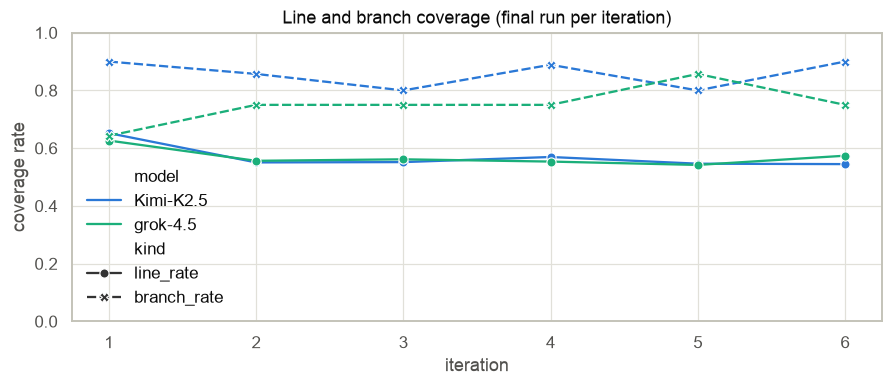

In [8]:
cov = data["coverage"]
if cov.empty:
    print("No coverage data.")
else:
    covl = cov.melt(id_vars=["model", "iteration"],
                    value_vars=["line_rate", "branch_rate"],
                    var_name="kind", value_name="rate")
    fig, ax = plt.subplots(figsize=(8, 3.4))
    sns.lineplot(data=covl, x="iteration", y="rate", hue="model", style="kind",
                 hue_order=HUE, palette=PAL, markers=True, estimator=None, ax=ax)
    ax.set_ylim(0, 1)
    ax.set_ylabel("coverage rate")
    ax.set_title("Line and branch coverage (final run per iteration)")
    display(cov.pivot_table(index="iteration", columns="model",
                            values="line_rate").round(3))

## Coverage distribution across all executions

ECDF over every measured execution: reads as "what share of runs reached at
most X coverage". Curves further right are better.

**Chart columns** — `line coverage rate` (x, 0–1) — of every coverage-bearing execution, retries included; `proportion` (y) — share of that model's executions with coverage ≤ x; line color — model.

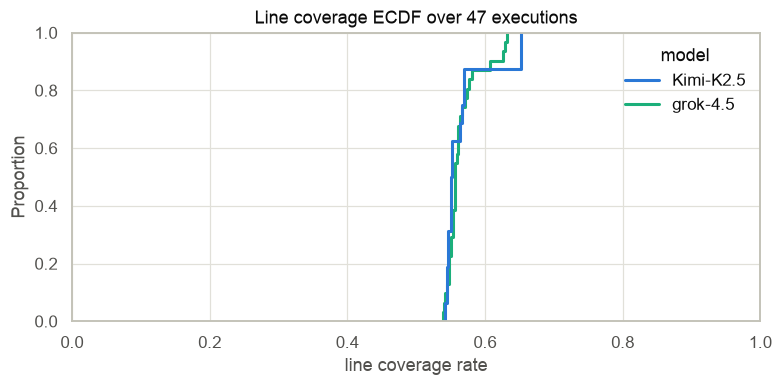

In [9]:
cov_all = tdd.load_coverage(STORY_ID, finals_only=False)
if cov_all.empty:
    print("No coverage data.")
else:
    fig, ax = plt.subplots(figsize=(7, 3.4))
    sns.ecdfplot(data=cov_all, x="line_rate", hue="model", hue_order=HUE,
                 palette=PAL, lw=2, ax=ax)
    ax.set_xlim(0, 1)
    ax.set_xlabel("line coverage rate")
    ax.set_title(f"Line coverage ECDF over {len(cov_all)} executions")

## Per-test durations (final runs)

Log-ish scale: durations are heavy-tailed. Consistently slow suites cost
wall-clock on every retry.

**Chart columns** — `model` (x); `test duration (s)` (y, symlog) — wall-clock of each individual test-method result from the final runs' `.trx` files; box — median/IQR; dots — test methods.

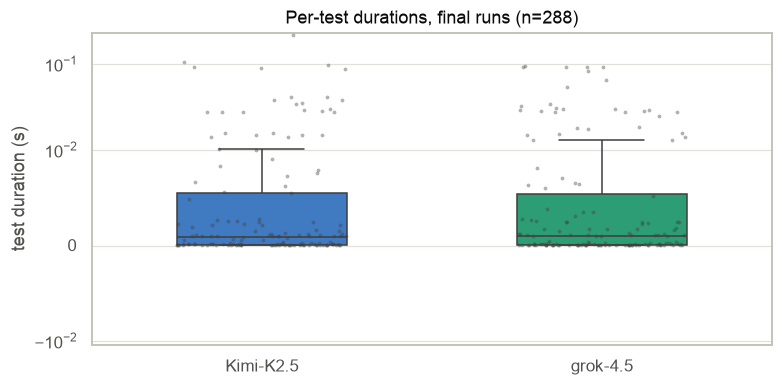

In [10]:
trx = data["trx"]
if trx.empty:
    print("No .trx data.")
else:
    fig, ax = plt.subplots(figsize=(7, 3.4))
    sns.boxplot(data=trx, x="model", y="duration_s", hue="model", order=HUE,
                hue_order=HUE, palette=PAL, legend=False, width=0.5,
                showfliers=False, ax=ax)
    sns.stripplot(data=trx, x="model", y="duration_s", order=HUE, color=".25",
                  size=2.5, alpha=0.4, jitter=0.25, ax=ax)
    ax.set_yscale("symlog", linthresh=0.01)
    ax.set_ylabel("test duration (s)")
    ax.set_xlabel("")
    ax.set_title(f"Per-test durations, final runs (n={len(trx)})")

## Sanity checks

In [11]:
if not t.empty:
    pr = t["pass_rate"].dropna()
    assert pr.between(0, 1).all()
    assert (t["passed"] + t["failed"] + t["skipped"] <= t["total"] + 0).all() or True
if not data["coverage"].empty:
    assert data["coverage"]["line_rate"].between(0, 1).all()
print("sanity checks passed")

sanity checks passed
